# Demonstrate connection between eigenvalues / eigenvectors and Principal Component Analysis (PCA)

## First some Eigenvalue problems with simple matrices

Show how a matrix $A$ multiplies a vector $x$ along the eigenvectors.

In [1]:
import numpy as np
np.set_printoptions(precision=3)

import matplotlib.pyplot as plt
plt.rcParams['image.origin'] = 'upper'
plt.rcParams['figure.figsize'] = (6, 6)

A:
 [[2 0]
 [0 2]]
T:
 [[1. 0.]
 [0. 1.]]
Eigenvalues:  [2. 2.]


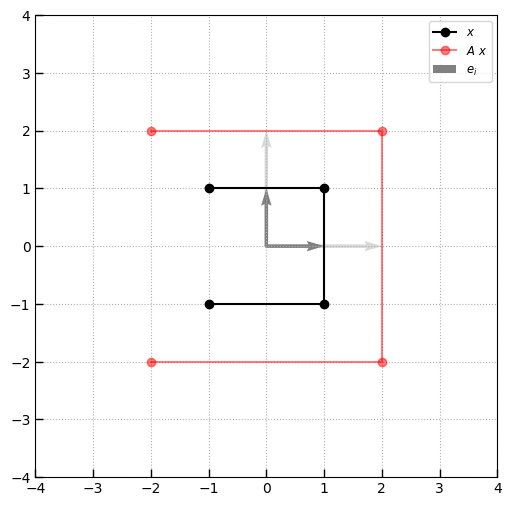

In [2]:
# Coordinate transformations

def draw_eigen(A):
    """
    Plot transformation of A on a coordinate grid and show eigenvectors
    """
    # For plotting the transformation
    i = np.array([-1,1,1,-1])
    j = np.array([-1,-1,1,1])
    x = np.array([i, j])

    fig, ax = plt.subplots(1,1,figsize=(6,6))
    
    plt.plot(*x, color='k', marker='o', label='$x$')
    xp = A @ x
    ax.plot(*xp, color='r', marker='o', alpha=0.5, label='$A~x$')

    eva, eve = np.linalg.eig(A)

    for k, va in enumerate(eva):
        ve = eve[:,k]

        label = '$e_i$' if k == 0 else None
            
        ax.quiver(0, 0, *(ve).real, angles='xy', scale_units='xy', scale=1, color='0.5', label=label)
        ax.quiver(0, 0, *(ve*va).real, angles='xy', scale_units='xy', scale=1, color='0.5', alpha=0.3)
        ax.quiver(0, 0, *(ve*va).imag, angles='xy', scale_units='xy', scale=1, color='0.5')

    print('A:\n', A)
    print('T:\n', eve)
    ax.legend()
    
    print('Eigenvalues: ', eva)
    ax.set_aspect(1)
    ax.set_xlim(-4,4)
    ax.set_ylim(-4,4)
    
    ax.grid()

A = np.array([
    [2, 0],
    [0, 2]
])

draw_eigen(A)

A:
 [[2 0]
 [0 1]]
T:
 [[1. 0.]
 [0. 1.]]
Eigenvalues:  [2. 1.]


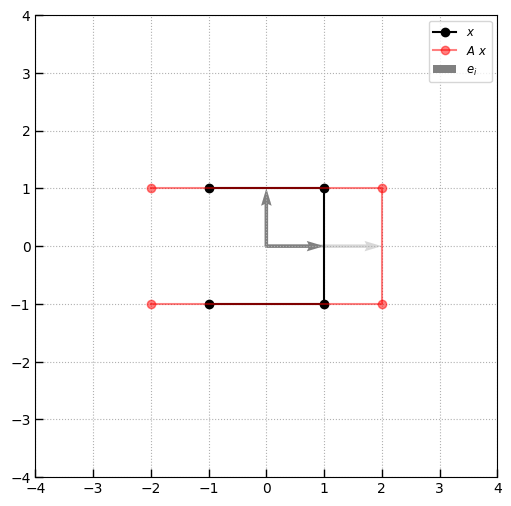

In [3]:
draw_eigen(
    np.array([
        [2, 0],
        [0, 1]
    ])
)

A:
 [[2 1]
 [1 2]]
T:
 [[ 0.707 -0.707]
 [ 0.707  0.707]]
Eigenvalues:  [3. 1.]


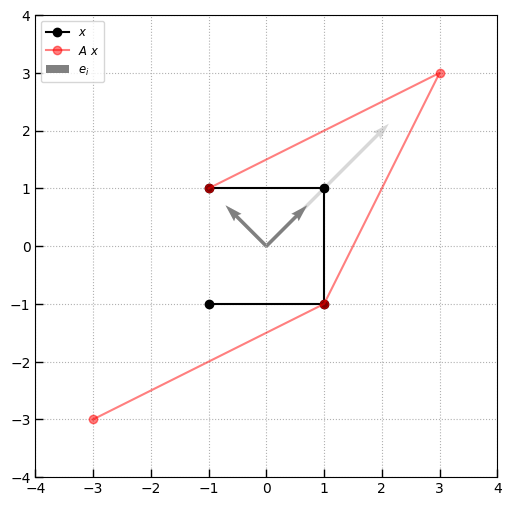

In [4]:
draw_eigen(
    np.array([
        [2, 1],
        [1, 2]
    ])
)

A:
 [[2 1]
 [0 1]]
T:
 [[ 1.    -0.707]
 [ 0.     0.707]]
Eigenvalues:  [2. 1.]


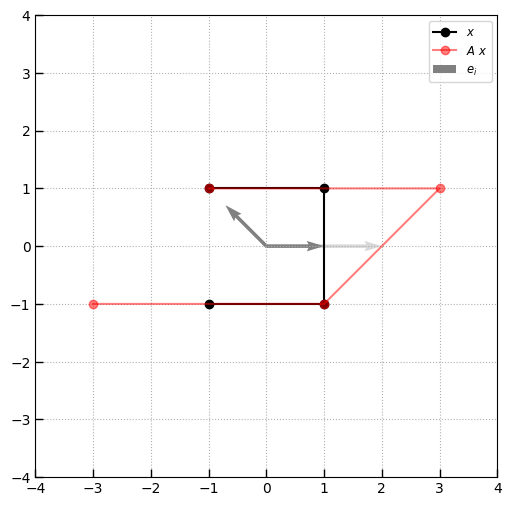

In [5]:
draw_eigen(
    np.array([
        [2, 1],
        [0, 1]
    ])
)

A:
 [[2 1]
 [1 2]]
T:
 [[ 0.707 -0.707]
 [ 0.707  0.707]]
Eigenvalues:  [3. 1.]


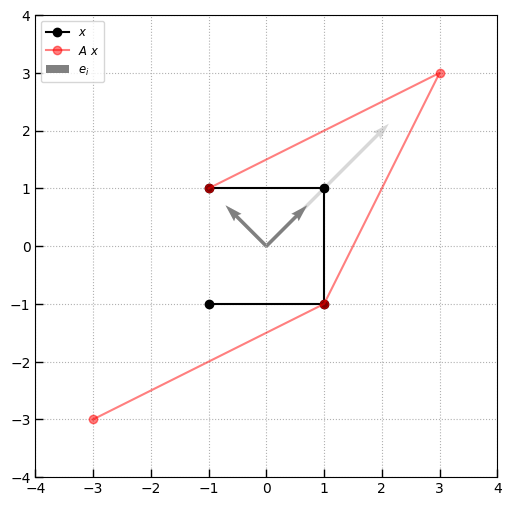

In [6]:
draw_eigen(
    np.array([
        [2, 1],
        [1, 2]
    ])
)

A:
 [[2.  1. ]
 [1.  1.5]]
T:
 [[ 0.788 -0.615]
 [ 0.615  0.788]]
Eigenvalues:  [2.781 0.719]


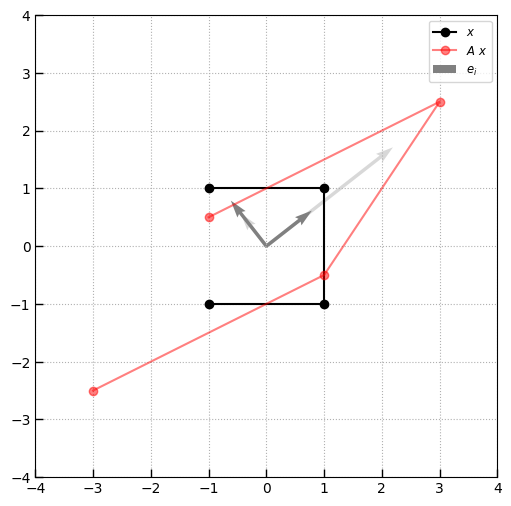

In [7]:
draw_eigen(
    np.array([
        [2, 1.0],
        [1, 1.5]
    ])
)

A:
 [[1 1]
 [1 1]]
T:
 [[ 0.707 -0.707]
 [ 0.707  0.707]]
Eigenvalues:  [2. 0.]


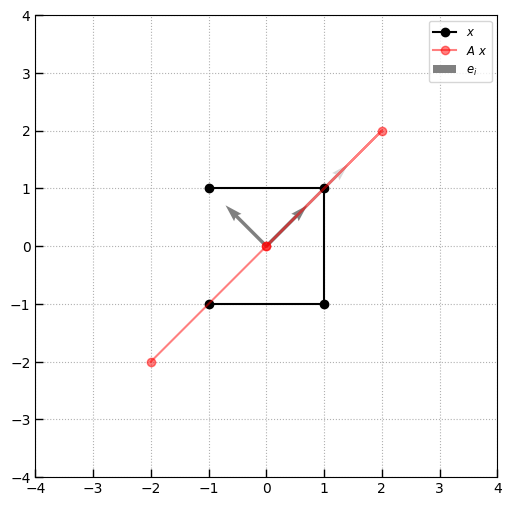

In [8]:
draw_eigen(
    np.array([
        [1, 1],
        [1, 1]
    ])
)

## "Defective matrix"

Geometric multiplicity < Algebraic Multiplicity

Linear independence of eigenvectors can be demonstrated with the rank of $\{T_j\}$ where $\lambda = \lambda_j$, i.e., the geometric multiplicity.

A:
 [[2 0]
 [0 2]]
T:
 [[1. 0.]
 [0. 1.]]
Eigenvalues:  [2. 2.]
rank L:  2


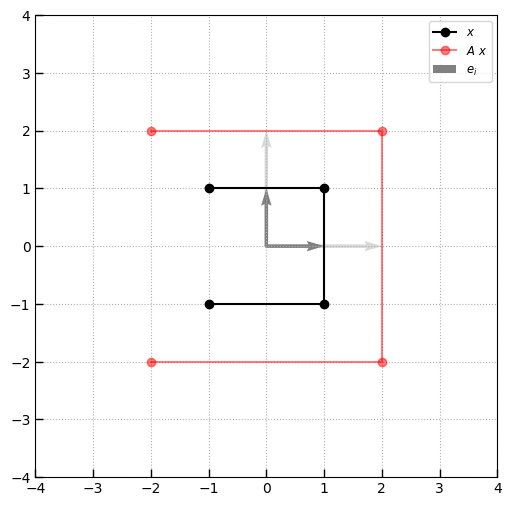

In [9]:
# Non-defective
A = np.array([
    [2, 0],
    [0, 2]
])

draw_eigen(A)

eva, eve = np.linalg.eig(A)
print('rank L: ', np.linalg.matrix_rank(eve))

In [10]:
A.dot(eve[0]), eve[0]*eva[0]

(array([2., 0.]), array([2., 0.]))

A:
 [[2 1]
 [0 2]]
T:
 [[ 1.000e+00 -1.000e+00]
 [ 0.000e+00  4.441e-16]]
Eigenvalues:  [2. 2.]
rank L:  1


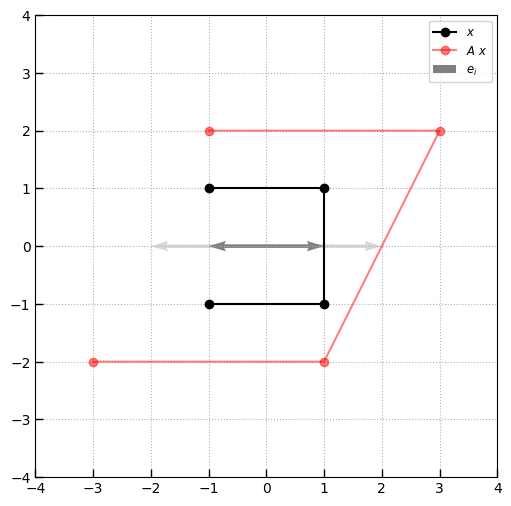

In [11]:
# Defective
A = np.array([
    [2, 1],
    [0, 2]
])

draw_eigen(A)

eva, eve = np.linalg.eig(A)
print('rank L: ', np.linalg.matrix_rank(eve))

## "Rotation matrix": eigenvectors are complex

A:
 [[ 0.707 -0.707]
 [ 0.707  0.707]]
T:
 [[0.707+0.j    0.707-0.j   ]
 [0.   -0.707j 0.   +0.707j]]
Eigenvalues:  [0.707+0.707j 0.707-0.707j]


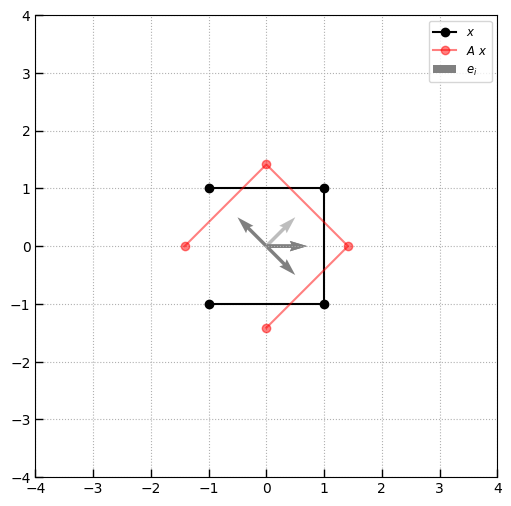

In [12]:
theta = 45/180*np.pi
Rx, Ry = 1., 1
A = np.array([[Rx*np.cos(theta), -Ry*np.sin(theta)],
              [Rx*np.sin(theta), Ry*np.cos(theta)]])

draw_eigen(A)

# Principal Component Analysis

The statistical technique of Principal Component Analysis is technique of feature extraction / dimensionality reduction that is directly related to Eigensystem problems.

Define the covariance matrix

$ A = Cov^{n \times n} = D^T D $ 

of a dataset $D^{m\times n}$ with $m$ samples of $n$ features.  $Cov$ describes the correlations in features $n$ across the dataset $m$, where positive values indicate positive correlations between features and negative values indicate anticorrelations.  

If we set up the eigensystem 

$ A x = \lambda x$,

then the eigenvectors $x$ describe the covariance of the feautures where the eigenvector $x_1$ corresponding to the largest eigenvector $\lambda_1$ points along the direction of maximum variance.  

Note that because $Cov$ is real symmetric, the eigenvectors $T$ are an orthonormal basis and $\Lambda$ is real diagonal.

Let's set up a toy problem to look at the projections between the data space $D$ and the eigenvectors $T$.  We  set up two components to a real "signal" corresponding to an oscillating component and an underlying linear trend.


## First a simple example

(-4.0, 4.0)

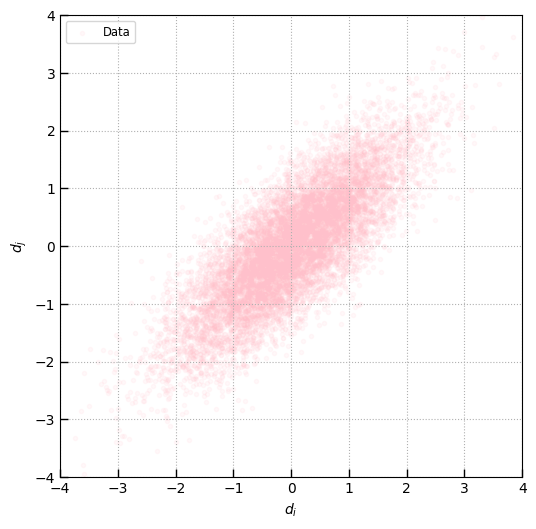

In [13]:
# Input covariance
input_cov = np.array([[1,0.8], [0.8, 1]])
mu = np.zeros(2)
D = np.random.multivariate_normal(mu, input_cov, 10000)

fig, ax = plt.subplots(1,1,figsize=(6,6))

i = 0
j = 1

ax.scatter(D[:,i], D[:,j], alpha=0.1, color='pink', label='Data')
ax.legend()
ax.grid()
ax.set_xlabel(r'$d_{i}$')
ax.set_ylabel(r'$d_{j}$')
ax.set_aspect(1)
ax.set_xlim(-4,4)
ax.set_ylim(-4,4)

In [14]:
###
# Covariance
Cov = D.T @ D
Cov /= Cov[0][0]

print('Input covariance: \n', input_cov)

print('Data covariance: \n', Cov)

Input covariance: 
 [[1.  0.8]
 [0.8 1. ]]
Data covariance: 
 [[1.    0.788]
 [0.788 0.973]]


A:
 [[1.    0.788]
 [0.788 0.973]]
T:
 [[ 0.713 -0.701]
 [ 0.701  0.713]]
Eigenvalues:  [1.775 0.198]


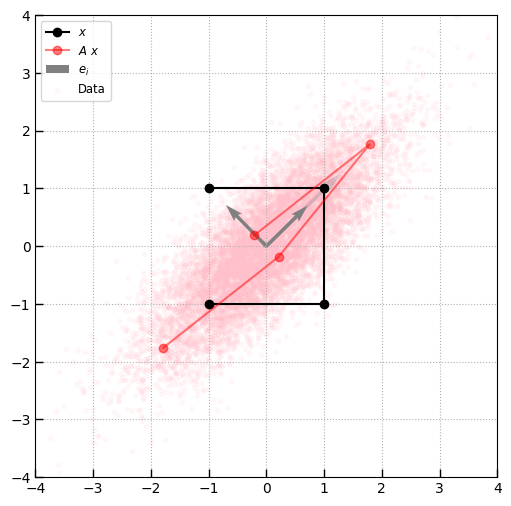

In [15]:
# Plot the transformation
draw_eigen(Cov)
ax = plt.gca()
ax.scatter(*D.T, alpha=0.1, color='pink', zorder=-1000, label='Data')
ax.legend(loc='upper left')

## Higher dimensional problem

Signal:

$s_1(t) = t$

$s_2(t) = \cos(\omega t)$

$S(t) = a_1 s_1(t) + a_2 s_2(t) + N(0,\epsilon)$.

Text(0.5, 0, '$t$')

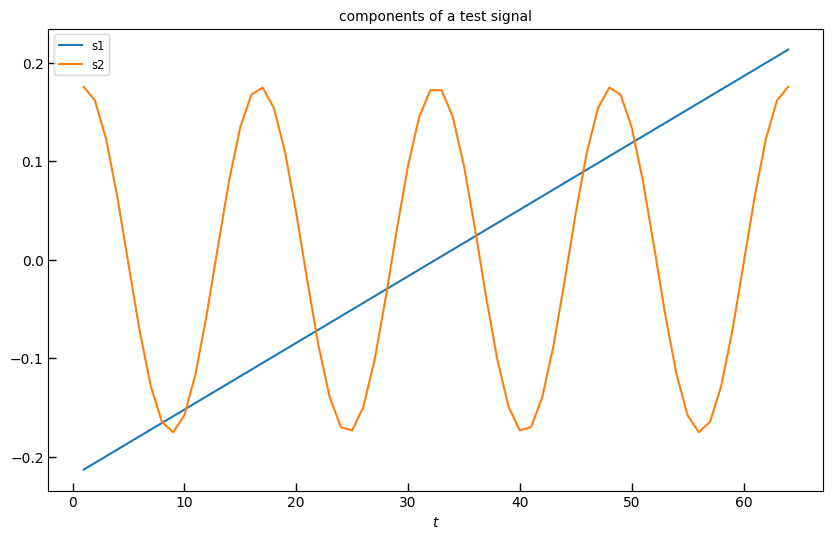

In [16]:
plt.rcParams['figure.figsize'] = (10, 6)

N = 64

x = np.linspace(-1,1,N)
xpl = np.arange(N)+1

# First component of a signal - linear trend
s1 = x*1 # trend
s1 /= np.linalg.norm(s1, ord=2)

# Second component of a signal - oscillating
s2 = np.cos(x*4*np.pi) # signal
s2 /= np.linalg.norm(s2, ord=2)

plt.plot(xpl, s1, label='s1')
plt.plot(xpl, s2, label='s2')
plt.legend()
plt.title("components of a test signal")
plt.xlabel(r'$t$')

Now generate random combinations of these components of the signal and construct a dataset 

In [17]:
M = 100 # "samples"
eps = 0.1
np.random.seed(1) # reproducible random numbers

In [18]:
# Random scaling factors
a1 = (np.random.rand(M) - 0.5)*10/np.linalg.norm(s1, ord=np.inf)
a2 = (np.random.rand(M) - 0.5)/np.linalg.norm(s2, ord=np.inf)

D0 = a1[:,None]*s1 + a2[:,None]*s2 

# With noise
D = D0 + np.random.normal(size=(M, x.shape[0]))*eps

# More "data" to use later
c1 = (np.random.rand(M) - 0.5)*10/np.linalg.norm(s1, ord=np.inf)
c2 = (np.random.rand(M) - 0.5)/np.linalg.norm(s2, ord=np.inf)

C0 = c1[:,None]*s1 + c2[:,None]*s2 
C = C0 + np.random.normal(size=(M, x.shape[0]))*eps


In [19]:
# M (samples) x N (features)
D.shape

(100, 64)

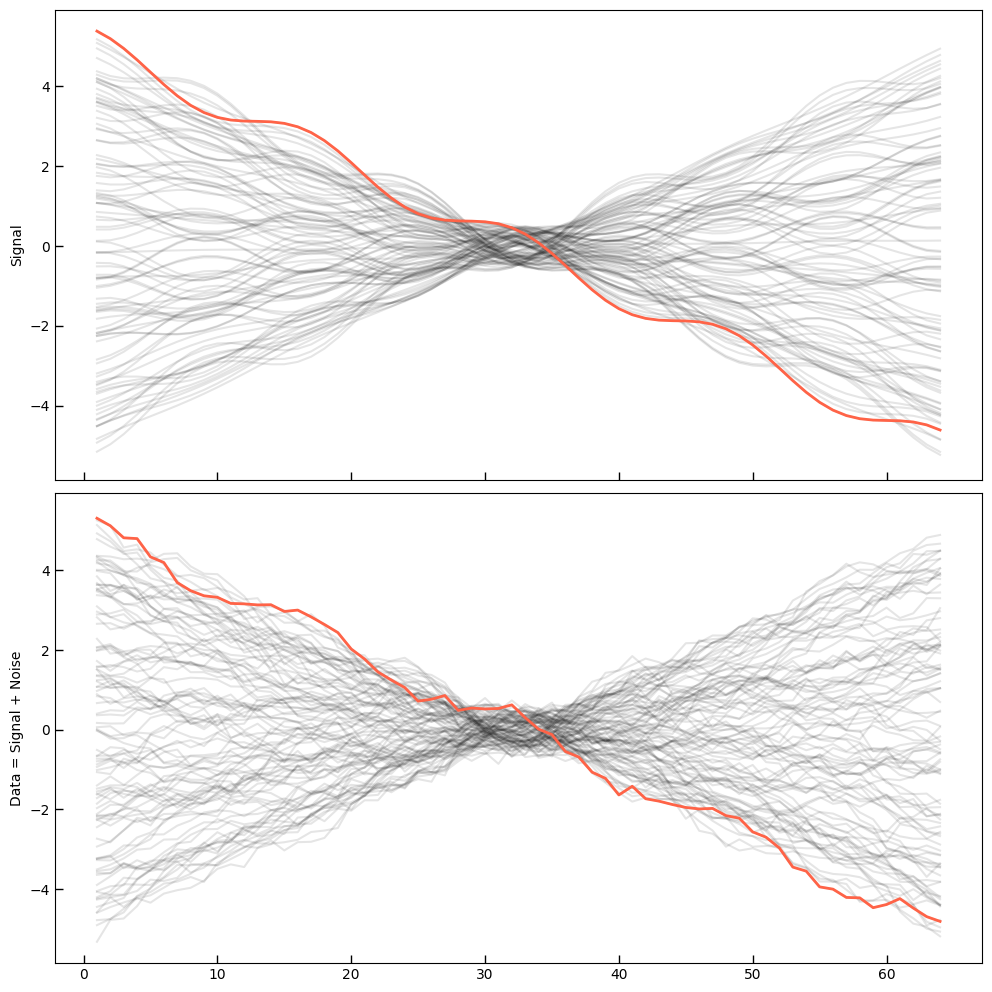

In [20]:
# Show the data
show_ix = 2 # one sample to pull out

fig, axes = plt.subplots(2,1,figsize=(10,10), sharex=True, sharey=True)

ax = axes[0]
ax.set_ylabel('Signal')
_ = ax.plot(xpl, D0.T, alpha=0.1, color='k')
_ = ax.plot(xpl, D0.T[:,show_ix], alpha=1, color='tomato', lw=2)

ax = axes[1]
ax.set_ylabel('Data = Signal + Noise')
_ = ax.plot(xpl, D.T, alpha=0.1, color='k')
_ = ax.plot(xpl, D.T[:,show_ix], alpha=1, color='tomato', lw=2)

fig.tight_layout(pad=1)

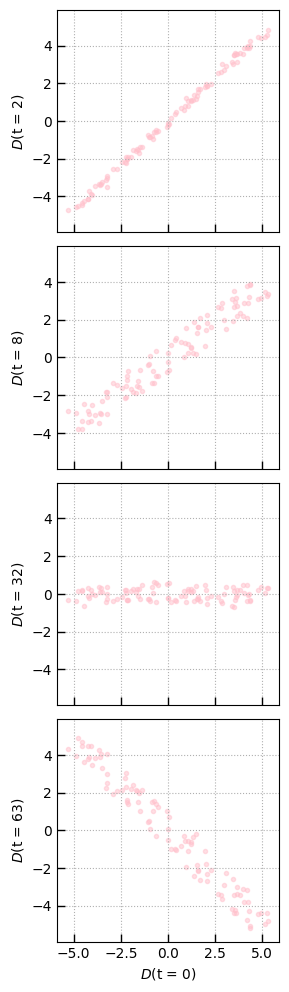

In [21]:
# Plot a few feature combinations (t_i vs. t_j)
fig, axes = plt.subplots(4,1,figsize=(3,10), sharex=True, sharey=True)

i = 0
j = 2

for ax, j in zip(axes, [2, 8, N//2, N - 1]):
    
    ax.scatter(D[:,i], D[:,j], alpha=0.5, color='pink') #, label='Data')
    # ax.legend()
    ax.grid()
    
    ax.set_aspect(1)
    ax.set_xlim(-5.9,5.9)
    ax.set_ylim(-5.9,5.9)

    ax.set_ylabel(r'$D$' + f'(t = {j})')

axes[3].set_xlabel(r'$D$'+ f'(t = {i})')
fig.tight_layout(pad=1)

In [22]:
# Compute eigenvalues and eigenvectors of covariance matrix D.T @ D
Cov = D.T @ D
eva, eve = np.linalg.eig(Cov)

Cov is symmetric:  True


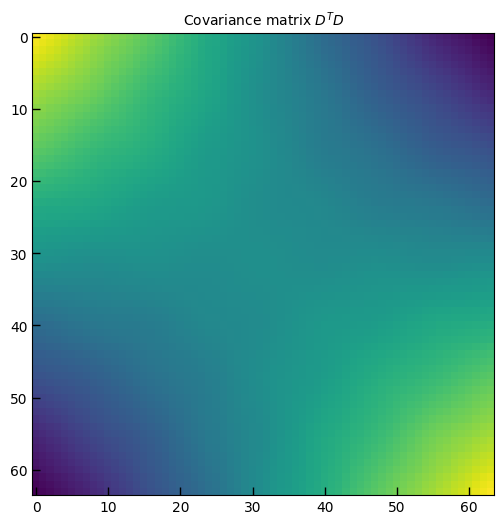

In [23]:
# The covariance matrix is symmetrix
import scipy.linalg
print('Cov is symmetric: ', scipy.linalg.issymmetric(Cov))
plt.imshow(Cov, origin='upper')
_ = plt.title(r'Covariance matrix $D^T D$')

In [24]:
T = eve
Tinv = np.linalg.inv(T)
# np.allclose((T1 @ Cov @ T), np.diag(eva))
print('A = Cov is symmetrix: ', np.allclose(Cov.T, Cov))
print('A = Cov is orthogonal: ', np.allclose(Cov.T @ Cov, Cov @ Cov.T))

A = Cov is symmetrix:  True
A = Cov is orthogonal:  True


Text(0, 0.5, '$\\lambda_k$')

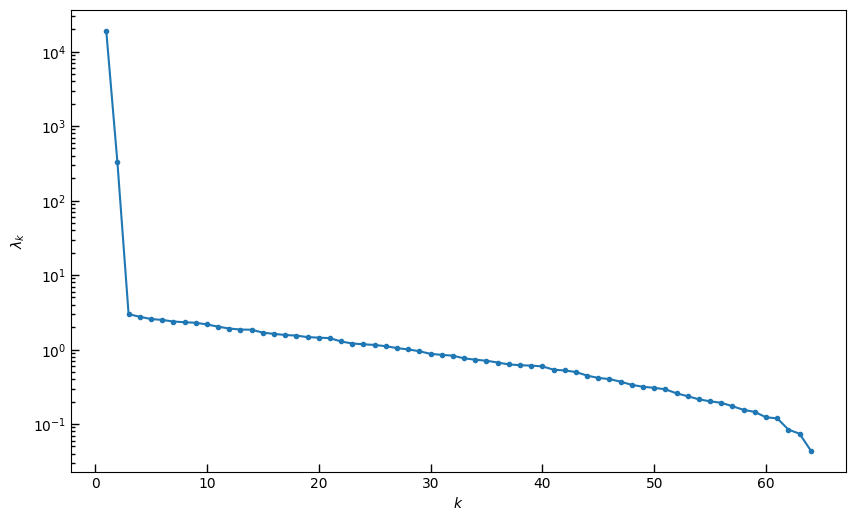

In [25]:
# Sort the eigenvalues and plot them
so = np.argsort(eva)[::-1]
sve = eve[:,so]
sva = eva[so]

plt.plot(np.arange(N)+1, eva[so], marker='.')
plt.semilogy()
plt.xlabel(r'$k$'); plt.ylabel(r'$\lambda_k$')

Text(0.5, 1.0, 'Eigenvectors')

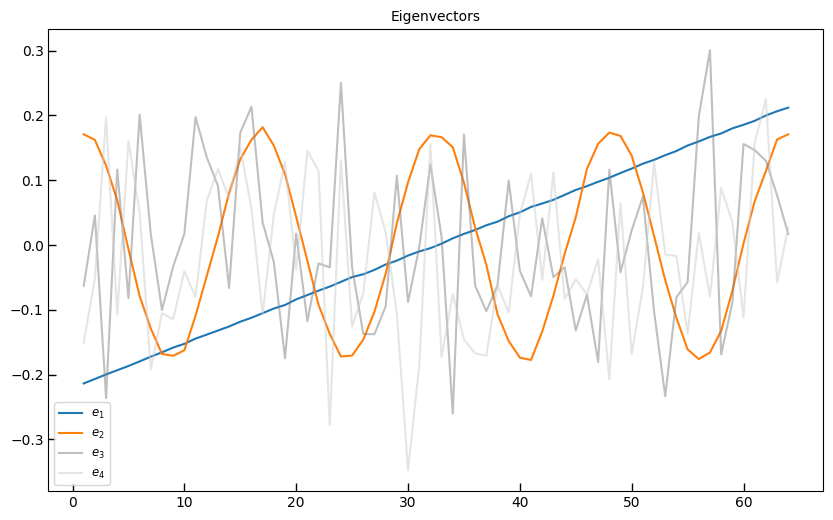

In [26]:
# plot first k eigenvectors
k = 2

for i in range(k):
    plt.plot(xpl, sve[:,i], label='$e_x$'.replace('x', f'{i+1}'))

# Next two (noise)
plt.plot(xpl, sve[:,k+1], color='0.5', alpha=0.5, label='$e_x$'.replace('x', f'{k+1}'))
plt.plot(xpl, sve[:,k+2], color='0.8', alpha=0.5, label='$e_x$'.replace('x', f'{k+2}'))
plt.legend()

plt.title('Eigenvectors')

Now the key to PCA is picking just the first $k$ "principle" components (starting with the largest $\lambda$).

Text(0, 0.5, '$\\alpha_k$ (out)')

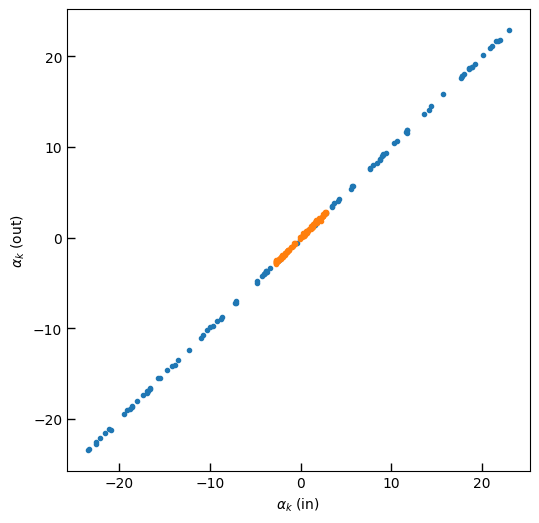

In [27]:
# Projection along the first k eigenvectors (k=2)
alpha = np.matmul(D, sve[:,:k])
reduced = alpha.dot(sve[:,:k].T)

# "signal" is data minus the first trend component
signal = D - alpha[:,:1].dot(sve[:,:1].T)

# Show projection coefficients alpha_i

plt.scatter(a1, alpha[:,0], label='k=1')
plt.scatter(a2, alpha[:,1], label='k=2')
plt.gca().set_aspect(1)

plt.xlabel(r'$\alpha_k$ (in)')
plt.ylabel(r'$\alpha_k$ (out)')

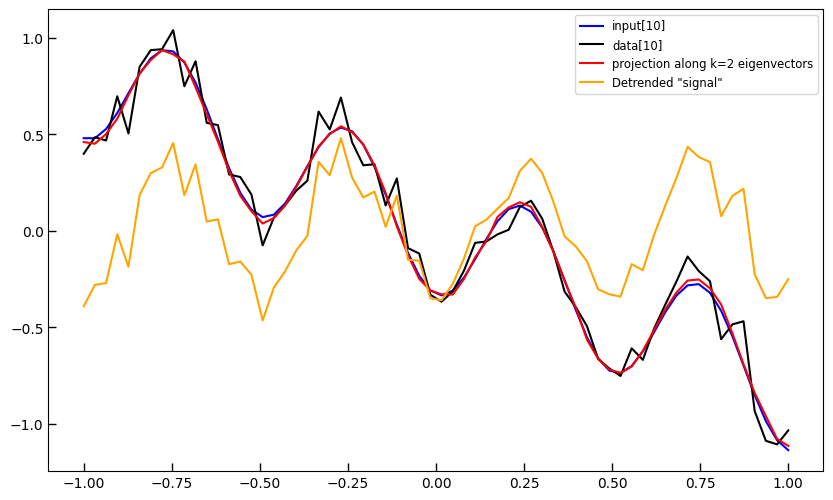

In [28]:
# Plot one result

i = 10

_ = plt.plot(x, D0.T[:,i], alpha=1, color='b', label=f'input[{i}]')
_ = plt.plot(x, D.T[:,i], alpha=1, color='k', label=f'data[{i}]')
_ = plt.plot(x, reduced.T[:,i], alpha=1, color='r', label=f'projection along k={k} eigenvectors')

_ = plt.plot(x, signal.T[:,i], alpha=1, color='orange', label=f'Detrended "signal"')

plt.legend()

## The full set of eigenvectors is an orthonormal basis that can reproduce any data exactly

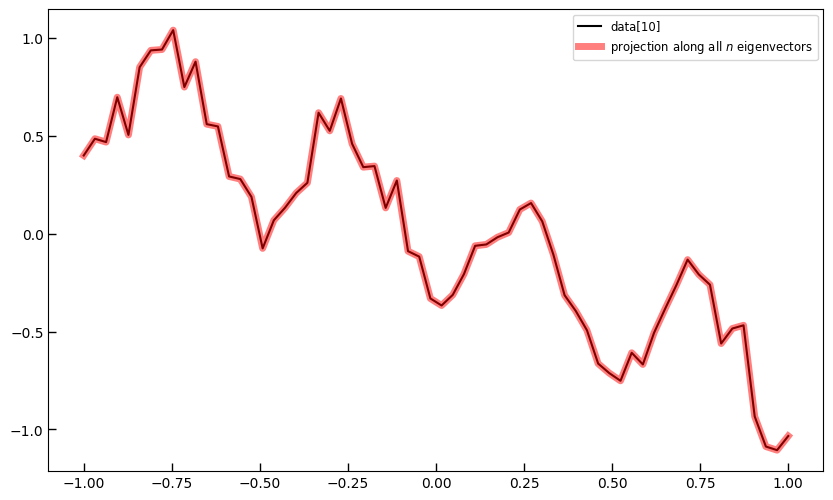

In [29]:
alpha = np.matmul(D, sve)
full = alpha.dot(sve.T)

_ = plt.plot(x, D.T[:,i], alpha=1, color='k', label=f'data[{i}]')
_ = plt.plot(x, full.T[:,i], color='r', label=f'projection along all $n$ eigenvectors', 
             lw=5, alpha=0.5)

plt.legend()

## Evaluate with new data that hasn't "seen" the eigenvectors / values before

Calculate the projection onto the principal dimensions

Text(0.5, 1.0, 'Projection of "new" data along $k=2$ principal components')

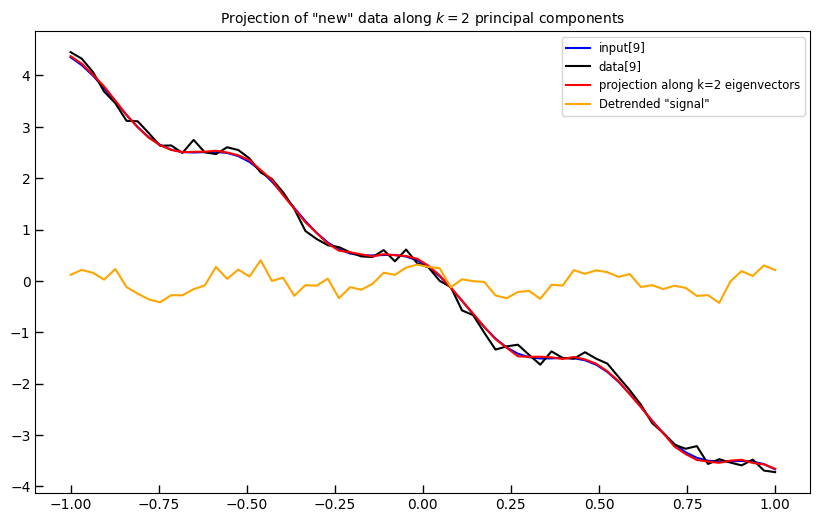

In [30]:

ishow = 9

alpha = np.matmul(C, sve[:,:k])
reduced = alpha.dot(sve[:,:k].T)
signal = C - alpha[:,:1].dot(sve[:,:1].T)

_ = plt.plot(x, C0.T[:,ishow], alpha=1, color='b', label=f'input[{ishow}]')
_ = plt.plot(x, C.T[:,ishow], alpha=1, color='k', label=f'data[{ishow}]')
_ = plt.plot(x, reduced.T[:,ishow], alpha=1, color='r', label=f'projection along k={k} eigenvectors')
_ = plt.plot(x, signal.T[:,i], alpha=1, color='orange', label=f'Detrended "signal"')

plt.legend()
plt.title('Projection of "new" data along $k=2$ principal components')